In [2]:
## Import Modules
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm.notebook import tqdm
warnings.filterwarnings("ignore")
%matplotlib inline
import tensorflow as tf
from keras.preprocessing.image import load_img
from keras.models import Sequential,Model
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D, Input
from PIL import Image
import joblib 
joblib_Filename = "age_and_gender_predictor.pkl" 

**Loading the dataset**


In [3]:
BASE_DIR = "/kaggle/input/utkface-new/UTKFace/"

In [4]:
#LABElS = AGE, GENDER , ETHNICITY
image_paths = []
age_labels = []
gender_labels = []

for filename in tqdm(os.listdir(BASE_DIR)):
    image_path = os.path.join(BASE_DIR , filename)
    temp = filename.split('_')
    age = int(temp[0])
    gender = int(temp[1])
    image_paths.append(image_path)
    age_labels.append(age)
    gender_labels.append(gender)

  0%|          | 0/23708 [00:00<?, ?it/s]

In [5]:
#converting it into dataframe
df = pd.DataFrame()
df['image'],df['age'],df['gender'] = image_paths, age_labels, gender_labels
df.head(10)

,image,age,gender
0,/kaggle/input/utkface-new/UTKFace/26_0_2_20170...,26,0
1,/kaggle/input/utkface-new/UTKFace/22_1_1_20170...,22,1
2,/kaggle/input/utkface-new/UTKFace/21_1_3_20170...,21,1
3,/kaggle/input/utkface-new/UTKFace/28_0_0_20170...,28,0
4,/kaggle/input/utkface-new/UTKFace/17_1_4_20170...,17,1
5,/kaggle/input/utkface-new/UTKFace/44_0_3_20170...,44,0
6,/kaggle/input/utkface-new/UTKFace/35_0_2_20170...,35,0
7,/kaggle/input/utkface-new/UTKFace/76_0_0_20170...,76,0
8,/kaggle/input/utkface-new/UTKFace/36_1_0_20170...,36,1
9,/kaggle/input/utkface-new/UTKFace/34_0_3_20170...,34,0


In [6]:
#mapping labels for gender 
gender_dict = {0:'Male',1:'Female'}

**Exploratory Data Analysis**

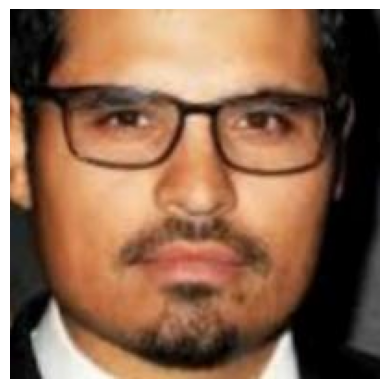

In [7]:
from PIL import Image
img = Image.open(df['image'][12334])
plt.axis('off')
plt.imshow(img);

<Axes: xlabel='age', ylabel='Density'>

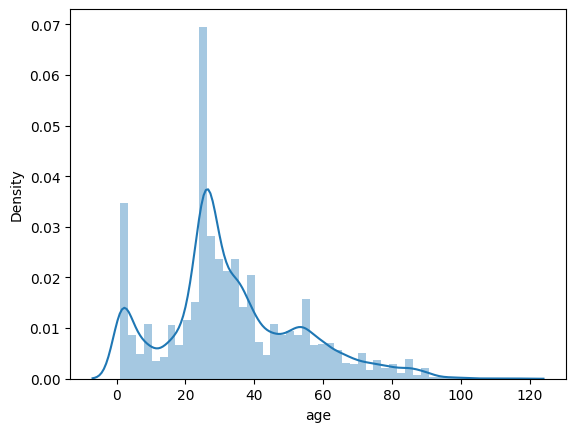

In [8]:
sns.distplot(df['age'])

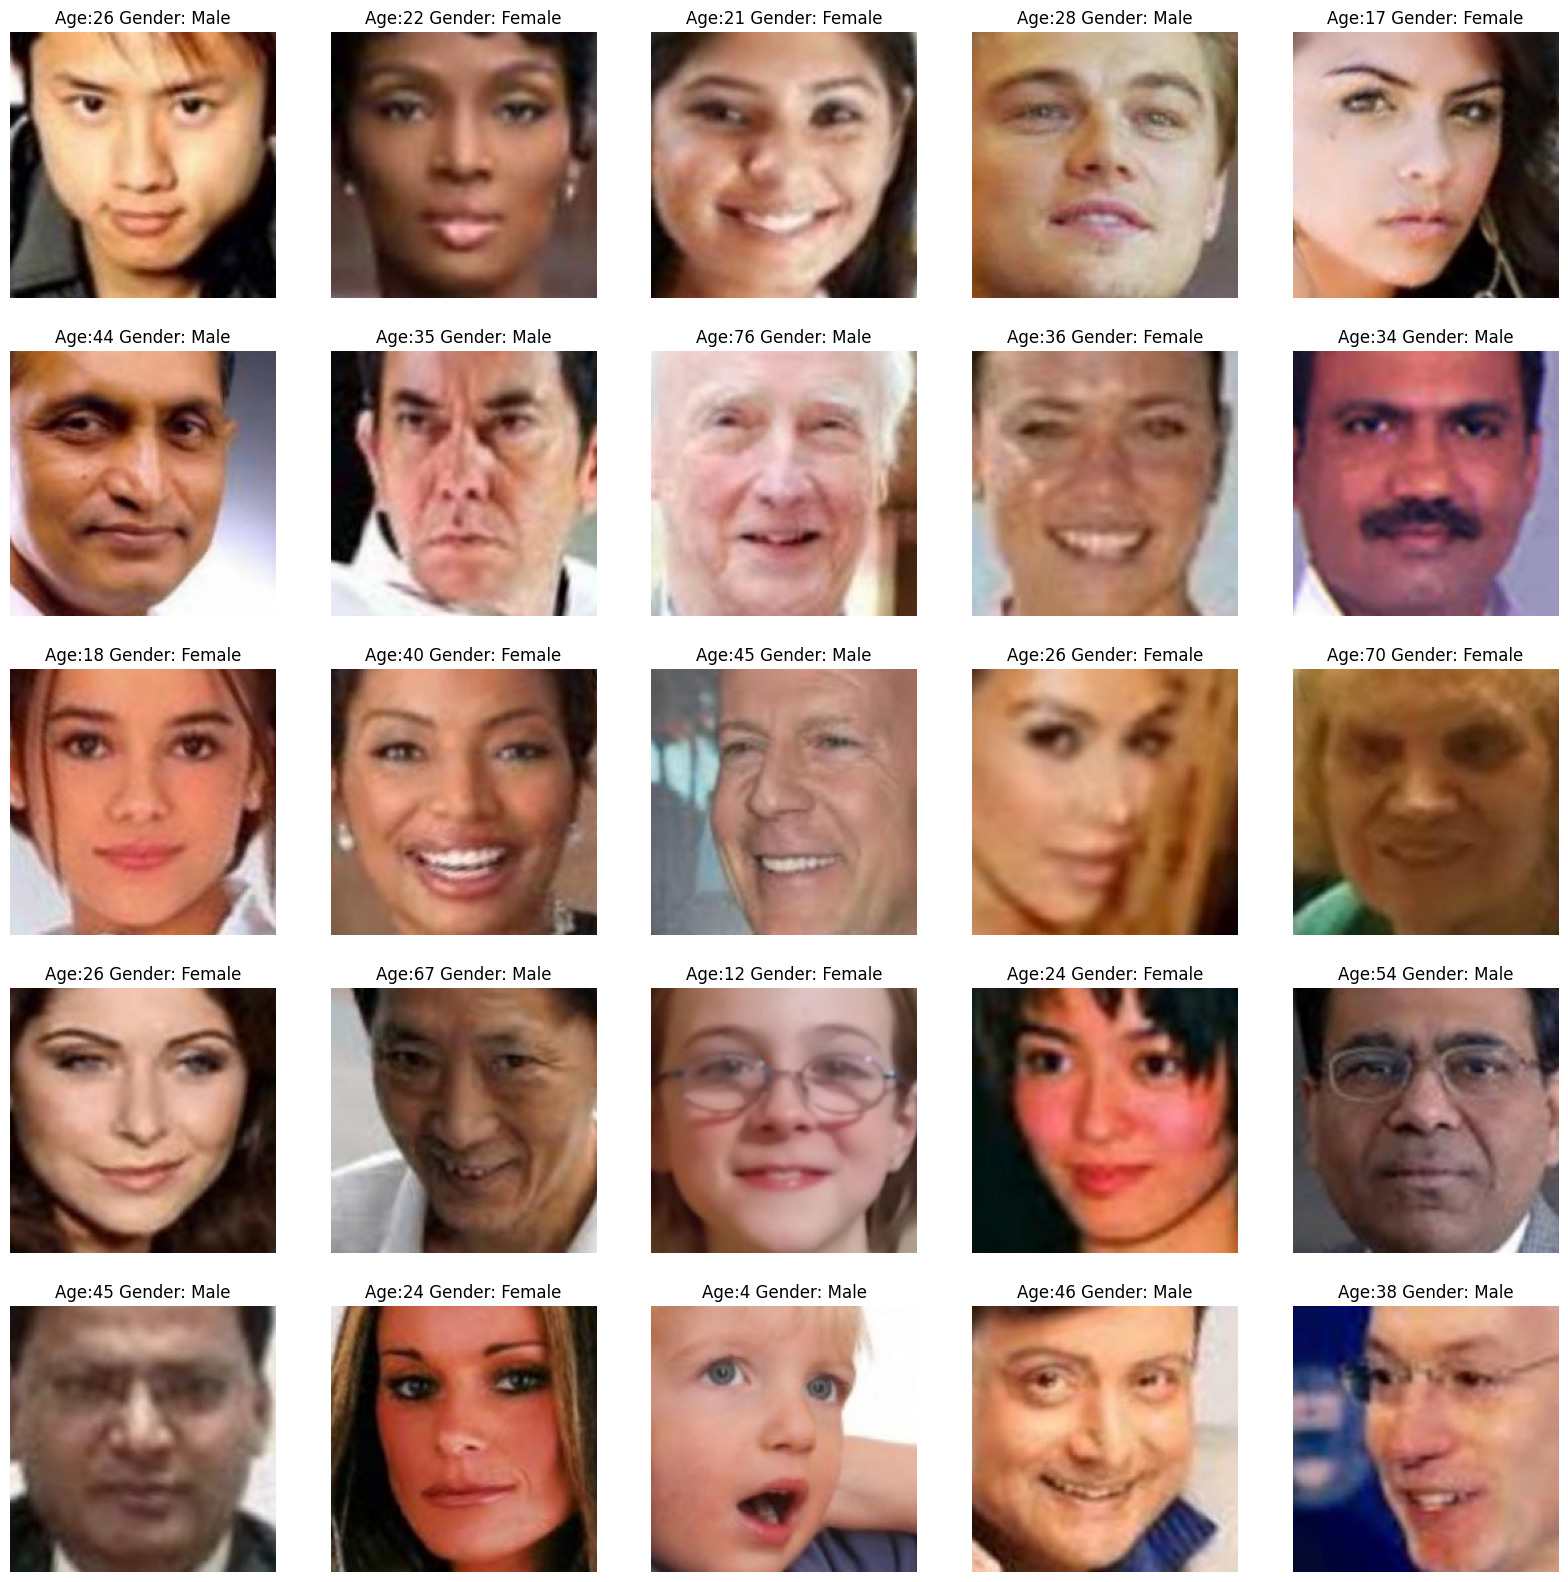

In [9]:
# to disply grid of images
plt.figure(figsize=(20,20))
files = df.iloc[0:25]
for index , file, age, gender in files.itertuples():
    plt.subplot(5, 5, index+1)
    img = load_img(file)
    img = np.array(img)
    plt.imshow(img)
    plt.title(f"Age:{age} Gender: {gender_dict[gender]}")
    plt.axis('off')

**Feature Extraction**

In [10]:
def extract_features(images):
    features = []
    for image in tqdm(images):
        img = load_img(image).convert('L')
        img = img.resize((128,128))
        img = np.array(img)
        features.append(img)

    features = np.array(features)
    features = features.reshape(len(features),128,128, 1)
    return features

In [11]:
X = extract_features(df['image'])

  0%|          | 0/23708 [00:00<?, ?it/s]

In [13]:
X.shape

(23708, 128, 128, 1)

In [14]:
#noramlize the images
X = X/255.0


In [15]:
y_gender = np.array(df['gender'])
y_age = np.array(df['age'])

In [16]:
input_shape = (128,128,1)

**Model Creation**

In [23]:
from tensorflow.keras.optimizers import SGD
inputs = Input((input_shape))
conv_1 = Conv2D(32,kernel_size = (3,3),activation = 'relu')(inputs)
maxp_1 = MaxPooling2D(pool_size=(2,2))(conv_1)
conv_2 = Conv2D(64,kernel_size = (3,3),activation = 'relu')(maxp_1)
maxp_2 = MaxPooling2D(pool_size=(2,2))(conv_1)
conv_3 = Conv2D(128,kernel_size = (3,3),activation = 'relu')(maxp_2)
maxp_3 = MaxPooling2D(pool_size=(2,2))(conv_1)
conv_4 = Conv2D(256,kernel_size = (3,3),activation = 'relu')(maxp_3)
maxp_4 = MaxPooling2D(pool_size=(2,2))(conv_1)

flatten = Flatten()(maxp_4)

#fully connected layers
dense_1 = Dense(256,activation = 'relu')(flatten)
dense_2 = Dense(256,activation = 'relu')(flatten)

dropout_1 = Dropout(0.2)(dense_1)
dropout_2 = Dropout(0.2)(dense_2)

output_1 = Dense(1,activation = 'sigmoid',name = 'gender_out')(dropout_1)
output_2 = Dense(1,activation = 'relu',name = 'age_out')(dropout_2)

model = Model(inputs = [inputs], outputs=[output_1, output_2])
model.compile(loss=['binary_crossentropy','mae'],optimizer='AdamW',metrics=['accuracy','mae'])


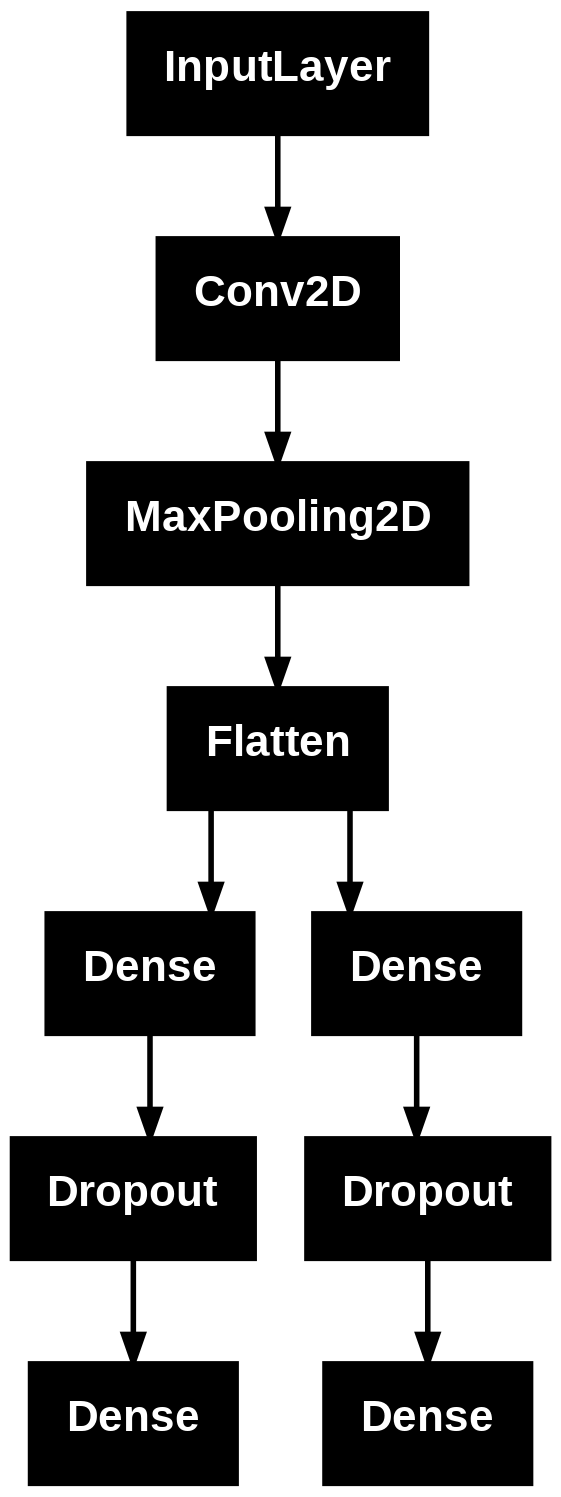

In [21]:
#plotting the model
from tensorflow.keras.utils import plot_model
plot_model(model)

In [22]:
#train model
history = model.fit(x= X,y = [y_gender,y_age],batch_size=32 , epochs= 30,validation_split=0.2)
model.save('my_model.keras')


Epoch 1/30


I0000 00:00:1775651159.190515     123 service.cc:148] XLA service 0x7991d800d8b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775651159.191126     123 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775651159.538374     123 cuda_dnn.cc:529] Loaded cuDNN version 90300


 13/593 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - age_out_loss: 22.4950 - age_out_mae: 22.4950 - gender_out_accuracy: 0.5007 - gender_out_loss: 4.2246 - loss: 26.7196

I0000 00:00:1775651162.034243     123 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


593/593 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - age_out_loss: 15.1477 - age_out_mae: 15.1477 - gender_out_accuracy: 0.7094 - gender_out_loss: 0.9692 - loss: 16.1169 - val_age_out_loss: 10.4812 - val_age_out_mae: 10.4766 - val_gender_out_accuracy: 0.8374 - val_gender_out_loss: 0.3479 - val_loss: 10.8247
Epoch 2/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - age_out_loss: 10.3543 - age_out_mae: 10.3543 - gender_out_accuracy: 0.8442 - gender_out_loss: 0.3493 - loss: 10.7035 - val_age_out_loss: 9.2184 - val_age_out_mae: 9.2250 - val_gender_out_accuracy: 0.8583 - val_gender_out_loss: 0.3101 - val_loss: 9.5359
Epoch 3/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - age_out_loss: 9.0614 - age_out_mae: 9.0614 - gender_out_accuracy: 0.8693 - gender_out_loss: 0.3005 - loss: 9.3619 - val_age_out_loss: 10.0208 - val_age_out_mae: 10.0308 - val_gender_out_accuracy: 0.8629 - val_gender_out_loss: 0.3125 - val_loss: 10.3437
Epoch 4/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - age_out_loss: 8.5614 - age_o

**Plot the Results**

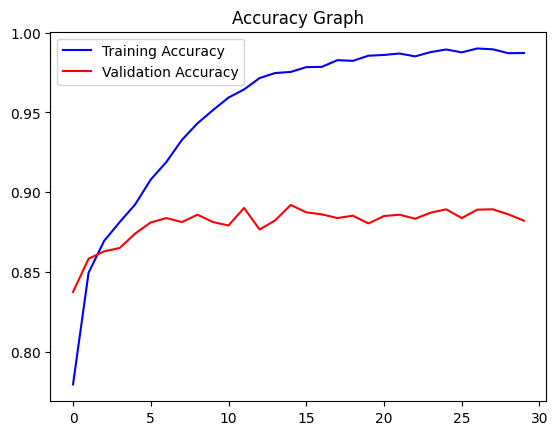

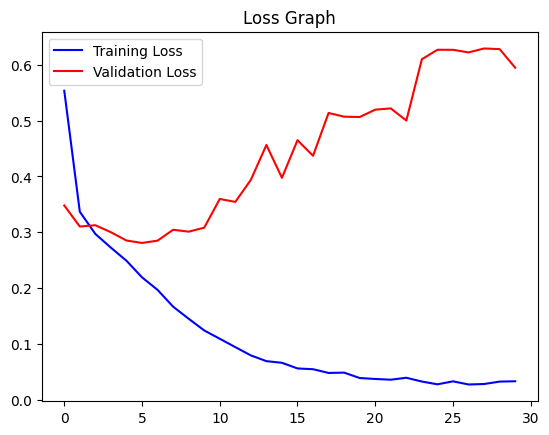

In [24]:
#plotting the result for gender
acc = history.history['gender_out_accuracy']
val_acc = history.history['val_gender_out_accuracy']
epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc,'r', label= 'Validation Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.figure()

loss = history.history['gender_out_loss']
val_loss = history.history['val_gender_out_loss']

plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss,'r', label= 'Validation Loss')
plt.title('Loss Graph')
plt.legend()
plt.show()

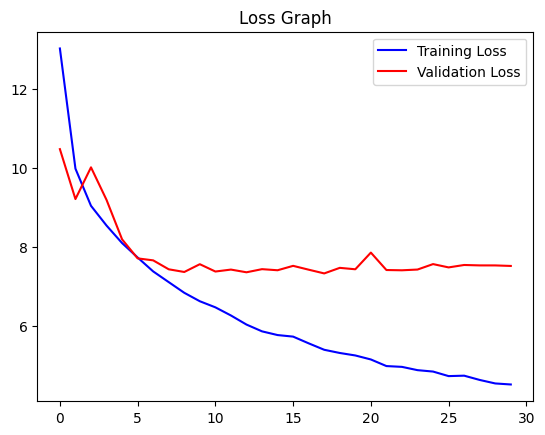

In [25]:
#plotting the result for age
loss = history.history['age_out_loss']
val_loss = history.history['val_age_out_loss']
epochs = range(len(acc))

plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss,'r', label= 'Validation Loss')
plt.title('Loss Graph')
plt.legend()
plt.show()

**Prediction with Test Data**

Original Gender: Female Original Age: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step
Predicted Gender: Male Predicted Age: 0


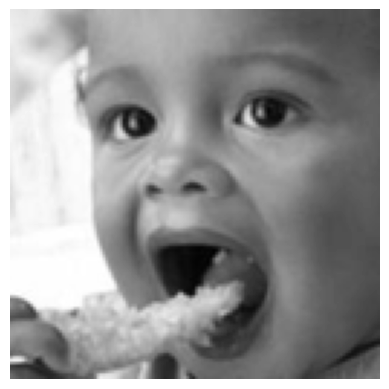

In [26]:
image_index = 348
print("Original Gender:",gender_dict[y_gender[image_index]],"Original Age:",y_age[image_index])
#pridiction from model
pred = model.predict(X[image_index].reshape(1,128,128,1))
pred_gender = gender_dict[round(pred[0][0][0])]
pred_age = round(pred[1][0][0])
print("Predicted Gender:",pred_gender,"Predicted Age:",pred_age)
plt.axis('off')
plt.imshow(X[image_index].reshape(128,128), cmap='gray');
